In [1]:
import os, io, time, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data");    DATA_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR  = OUT_DIR / "figures"; FIG_DIR.mkdir(exist_ok=True)

# Experiment configuration (single source of truth) 
START_YEAR   = 1990          # USGS global catalog is broadly complete for M>=4.5 from ~1990
MIN_MAG      = 4.5
CELL_SIZE    = 5.0           # degrees, for the spatial grid
MIN_EVENTS_PER_CELL = 250    # keep only seismically active cells
SEQ_LEN      = 12            # months of history fed to the LSTM
BIG_MAG      = 5.5           # threshold for the "significant event" classification task

TRAIN_END = "2013-12-31"     # temporal split boundaries
VAL_END   = "2018-12-31"     # test = 2019-01-01 -> today

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("Setup complete.")

Setup complete.


In [2]:
RAW_PATH = DATA_DIR / f"usgs_M{str(MIN_MAG).replace('.','')}_{START_YEAR}_present.csv"
USGS_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"

def fetch_chunk(start, end, min_mag=MIN_MAG, retries=3):
 
    params = {
        "format": "csv",
        "starttime": start.strftime("%Y-%m-%d"),
        "endtime": end.strftime("%Y-%m-%d"),
        "minmagnitude": min_mag,
        "orderby": "time-asc",
        "limit": 20000,
    }
    for attempt in range(retries):
        try:
            r = requests.get(USGS_URL, params=params, timeout=180)
            if r.status_code == 204:         
                return pd.DataFrame()
            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f"  retry {attempt+1} ({e})")
            time.sleep(5)

def download_catalog():
    edges = pd.date_range(f"{START_YEAR}-01-01", pd.Timestamp.today().normalize(), freq="QS")
    edges = list(edges) + [pd.Timestamp.today().normalize() + pd.Timedelta(days=1)]
    frames = []
    for i in range(len(edges) - 1):
        chunk = fetch_chunk(edges[i], edges[i + 1])
        if len(chunk):
            frames.append(chunk)
        if i % 8 == 0:
            print(f"  {edges[i].date()} -> {sum(len(f) for f in frames):,} events")
        time.sleep(0.4)                        
    return pd.concat(frames, ignore_index=True)

if RAW_PATH.exists():
    raw = pd.read_csv(RAW_PATH)
    print(f"Loaded cached catalog: {RAW_PATH}  ({len(raw):,} rows)")
else:
    print("Downloading USGS catalog (one-time, be patient)...")
    raw = download_catalog()
    raw.to_csv(RAW_PATH, index=False)
    print(f"Saved {len(raw):,} events to {RAW_PATH}")

raw.head(3)

Loaded cached catalog: data\usgs_M45_1990_present.csv  (230,256 rows)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1990-01-01T07:49:35.570Z,-21.772,-179.361,599.5,5.4,mw,NaN,NaN,NaN,1.1,us,usp00043tf,2025-12-19T21:02:54.084Z,Fiji region,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
1,1990-01-01T09:03:12.880Z,36.417,140.568,67.9,4.8,mb,NaN,NaN,NaN,1.2,us,usp00043tg,2014-11-07T00:45:26.659Z,"3 km NE of Hitachi-Naka, Japan",earthquake,NaN,6.5,NaN,12.0,reviewed,us,us
2,1990-01-01T09:38:15.390Z,-23.616,-179.922,540.8,4.8,mb,NaN,NaN,NaN,1.0,us,usp00043tj,2014-11-07T00:45:26.695Z,south of the Fiji Islands,earthquake,NaN,19.5,NaN,5.0,reviewed,us,us


In [3]:
df = raw.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True, format="mixed")

before = len(df)
df = df.drop_duplicates(subset="id")
df = df[df["type"] == "earthquake"]
df = df.dropna(subset=["time", "latitude", "longitude", "mag"])
df = df[df["mag"] >= MIN_MAG]
df["depth"] = df["depth"].clip(lower=0)
df = df.sort_values("time").reset_index(drop=True)

print(f"{before:,} raw rows -> {len(df):,} clean earthquakes")
print(f"Period: {df['time'].min().date()} to {df['time'].max().date()}")

missing = df.isna().mean().sort_values(ascending=False)
print("\nMissing-value rate per column:")
print((missing[missing > 0] * 100).round(1).astype(str) + " %")

230,256 raw rows -> 230,130 clean earthquakes
Period: 1990-01-01 to 2026-09-17

Missing-value rate per column:
horizontalError    61.0 %
magError           58.5 %
dmin               57.8 %
nst                47.9 %
depthError         38.4 %
gap                26.1 %
magNst             16.3 %
rms                 2.2 %
dtype: object


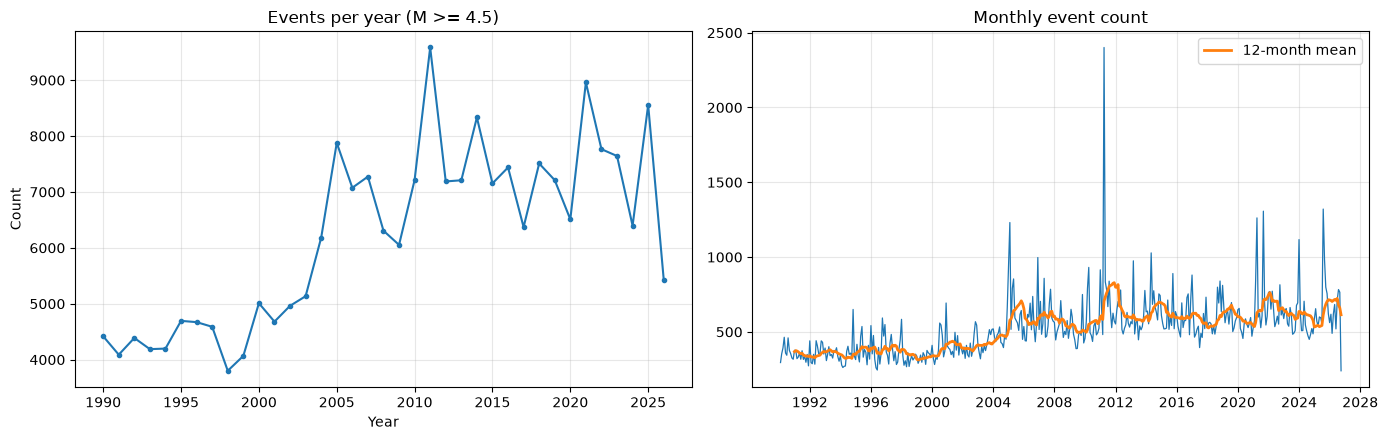

Mean events/year: 6242   std: 1600
Spikes are aftershock sequences following great earthquakes (e.g. 2004 Sumatra, 2011 Tohoku) - real signal, not artefacts.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

yearly = df.set_index("time").resample("YE").size()
ax[0].plot(yearly.index.year, yearly.values, marker="o", ms=3)
ax[0].set_title(f"Events per year (M >= {MIN_MAG})")
ax[0].set_xlabel("Year"); ax[0].set_ylabel("Count")

monthly = df.set_index("time").resample("ME").size()
ax[1].plot(monthly.index, monthly.values, lw=0.9)
ax[1].plot(monthly.index, monthly.rolling(12).mean(), lw=2, label="12-month mean")
ax[1].set_title("Monthly event count"); ax[1].legend()

plt.tight_layout(); plt.savefig(FIG_DIR / "temporal_counts.png", dpi=120); plt.show()

print(f"Mean events/year: {yearly.iloc[:-1].mean():.0f}   std: {yearly.iloc[:-1].std():.0f}")
print("Spikes are aftershock sequences following great earthquakes "
      "(e.g. 2004 Sumatra, 2011 Tohoku) - real signal, not artefacts.")

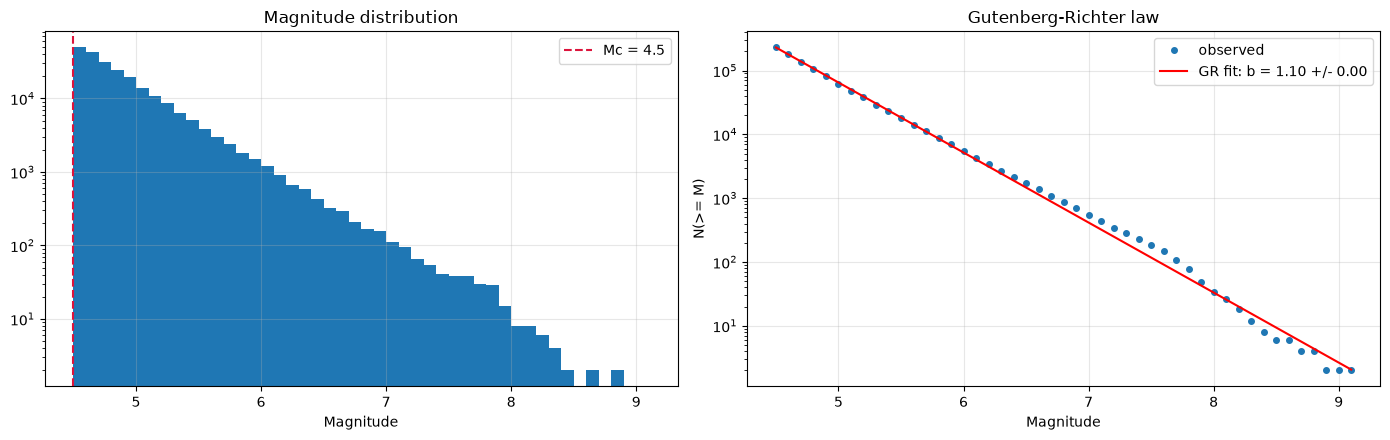

Mc = 4.50, b = 1.098 +/- 0.002
A b-value near 1.0 is the global norm. Low b <-> relatively more large events; b-value drops are studied as a stress proxy, so we use rolling b as an LSTM feature.


In [5]:

mags = df["mag"].values
bins = np.arange(MIN_MAG, mags.max() + 0.1, 0.1)
cum_counts = np.array([(mags >= m).sum() for m in bins])


hist, edges = np.histogram(mags, bins=bins)
Mc = edges[np.argmax(hist)]


sel = mags[mags >= Mc]
b = np.log10(np.e) / (sel.mean() - (Mc - 0.05))
b_err = b / np.sqrt(len(sel))
a = np.log10(len(sel)) + b * Mc

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(mags, bins=bins, edgecolor="none")
ax[0].axvline(Mc, color="crimson", ls="--", label=f"Mc = {Mc:.1f}")
ax[0].set_yscale("log"); ax[0].set_title("Magnitude distribution")
ax[0].set_xlabel("Magnitude"); ax[0].legend()

ax[1].semilogy(bins, cum_counts, "o", ms=4, label="observed")
xx = np.linspace(Mc, mags.max(), 50)
ax[1].semilogy(xx, 10 ** (a - b * xx), "r-", label=f"GR fit: b = {b:.2f} +/- {b_err:.2f}")
ax[1].set_title("Gutenberg-Richter law"); ax[1].set_xlabel("Magnitude")
ax[1].set_ylabel("N(>= M)"); ax[1].legend()

plt.tight_layout(); plt.savefig(FIG_DIR / "gutenberg_richter.png", dpi=120); plt.show()

print(f"Mc = {Mc:.2f}, b = {b:.3f} +/- {b_err:.3f}")
print("A b-value near 1.0 is the global norm. Low b <-> relatively more large events; "
      "b-value drops are studied as a stress proxy, so we use rolling b as an LSTM feature.")

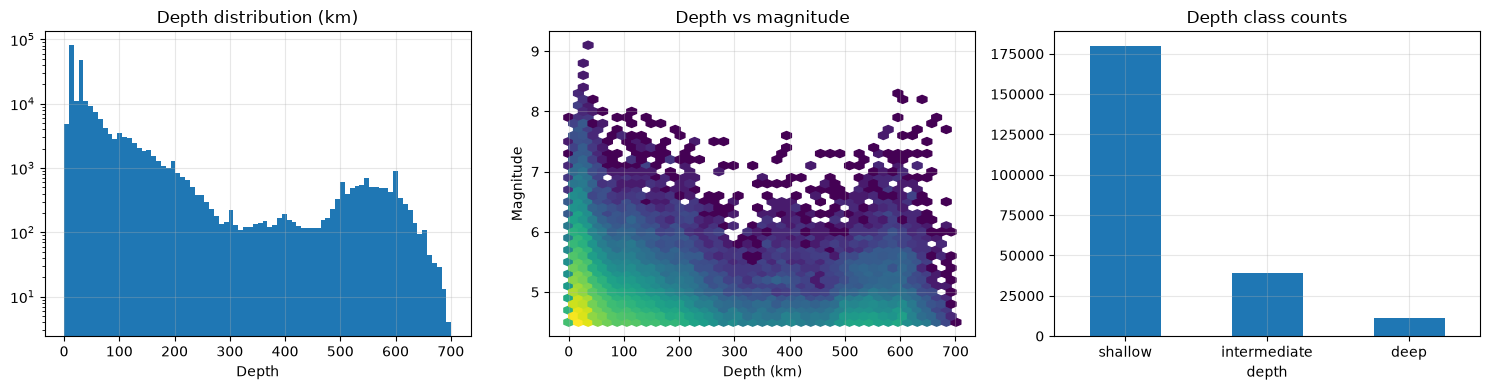

               count  mean  max
depth                          
shallow       179904  4.86  9.1
intermediate   39001  4.80  8.0
deep           11225  4.83  8.3

Note the 10 km spike: that is a fixed default depth the locator assigns when depth is poorly constrained. It is a processing artefact, worth knowing about.


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(df["depth"], bins=80)
ax[0].set_yscale("log"); ax[0].set_title("Depth distribution (km)")
ax[0].set_xlabel("Depth")

ax[1].hexbin(df["depth"], df["mag"], gridsize=40, bins="log", cmap="viridis")
ax[1].set_xlabel("Depth (km)"); ax[1].set_ylabel("Magnitude")
ax[1].set_title("Depth vs magnitude")

seg = pd.cut(df["depth"], [-1, 70, 300, 800], labels=["shallow", "intermediate", "deep"])
seg.value_counts().plot(kind="bar", ax=ax[2], rot=0)
ax[2].set_title("Depth class counts")

plt.tight_layout(); plt.savefig(FIG_DIR / "depth_eda.png", dpi=120); plt.show()

print(df.groupby(seg, observed=True)["mag"].agg(["count", "mean", "max"]).round(2))
print("\nNote the 10 km spike: that is a fixed default depth the locator assigns when "
      "depth is poorly constrained. It is a processing artefact, worth knowing about.")

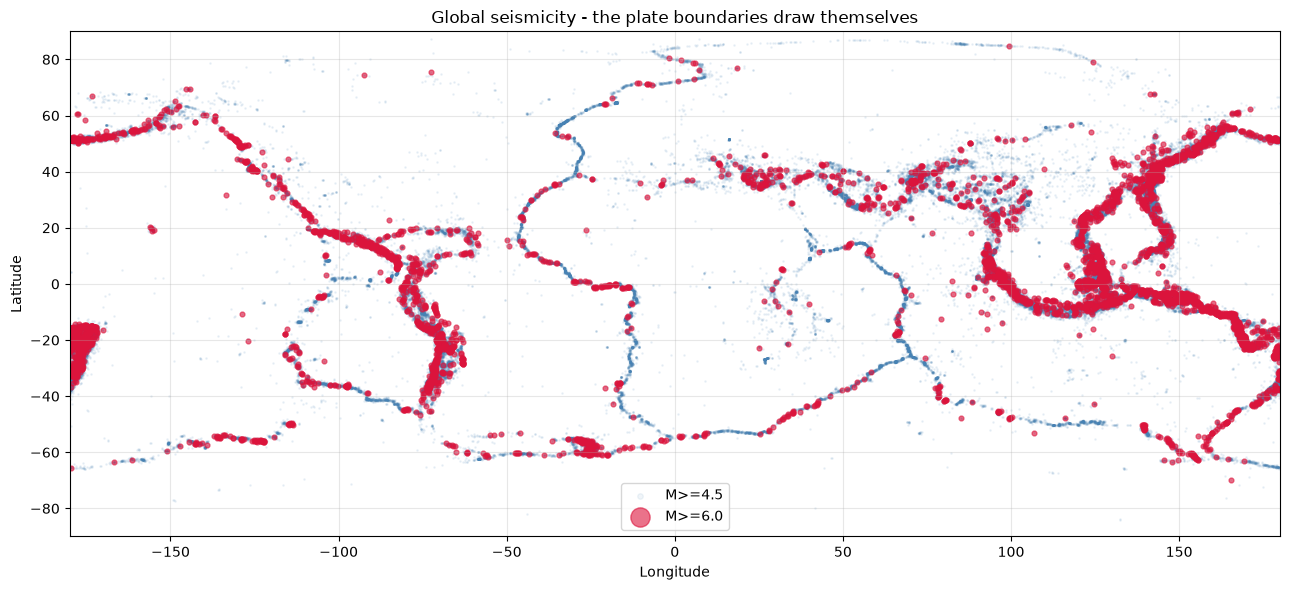

Top 12 regions by event count:
region
Indonesia                        28289
Japan                            15287
Papua New Guinea                 13339
Philippines                      12370
Russia                            9543
Tonga                             9485
Chile                             7706
Vanuatu                           6970
South Sandwich Islands region     5730
Alaska                            5718
Solomon Islands                   5156
New Zealand                       4677
Name: count, dtype: int64


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
big = df[df["mag"] >= 6.0]
ax.scatter(df["longitude"], df["latitude"], s=1, alpha=0.08, c="steelblue", label=f"M>={MIN_MAG}")
ax.scatter(big["longitude"], big["latitude"], s=12, alpha=0.6, c="crimson", label="M>=6.0")
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Global seismicity - the plate boundaries draw themselves")
ax.legend(markerscale=4)
plt.tight_layout(); plt.savefig(FIG_DIR / "world_map.png", dpi=120); plt.show()

df["region"] = df["place"].astype(str).str.split(",").str[-1].str.strip()
print("Top 12 regions by event count:")
print(df["region"].value_counts().head(12))

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LEAK_FEATS = ["latitude", "longitude", "depth", "nst", "gap", "dmin", "rms"]
sub = df.dropna(subset=LEAK_FEATS + ["mag"]).copy()
print(f"Rows usable for the original framing: {len(sub):,} "
      f"({len(sub)/len(df):.0%} of the catalog - the rest lack network metadata)")

def evaluate(y_true, y_pred, label):
    m = {"model": label,
         "MAE": mean_absolute_error(y_true, y_pred),
         "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
         "R2": r2_score(y_true, y_pred)}
    print(f"{label:<34} MAE {m['MAE']:.3f}  RMSE {m['RMSE']:.3f}  R2 {m['R2']:.3f}")
    return m

leak_results = []


Xr, yr = sub[LEAK_FEATS], sub["mag"]
Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
rf_rand = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
leak_results.append(evaluate(yte, rf_rand.predict(Xte), "RF, random split"))


cut = sub["time"].quantile(0.8)
tr, te = sub[sub["time"] <= cut], sub[sub["time"] > cut]
rf_time = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_time.fit(tr[LEAK_FEATS], tr["mag"])
leak_results.append(evaluate(te["mag"], rf_time.predict(te[LEAK_FEATS]), "RF, temporal split"))


GEO = ["latitude", "longitude", "depth"]
rf_geo = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_geo.fit(tr[GEO], tr["mag"])
leak_results.append(evaluate(te["mag"], rf_geo.predict(te[GEO]), "RF, geo-only, temporal split"))

leak_results.append(evaluate(te["mag"], np.full(len(te), tr["mag"].mean()), "Baseline: predict the mean"))

Rows usable for the original framing: 33,494 (15% of the catalog - the rest lack network metadata)
RF, random split                   MAE 0.173  RMSE 0.258  R2 0.534
RF, temporal split                 MAE 0.173  RMSE 0.261  R2 0.510
RF, geo-only, temporal split       MAE 0.272  RMSE 0.377  R2 -0.018
Baseline: predict the mean         MAE 0.269  RMSE 0.374  R2 -0.002


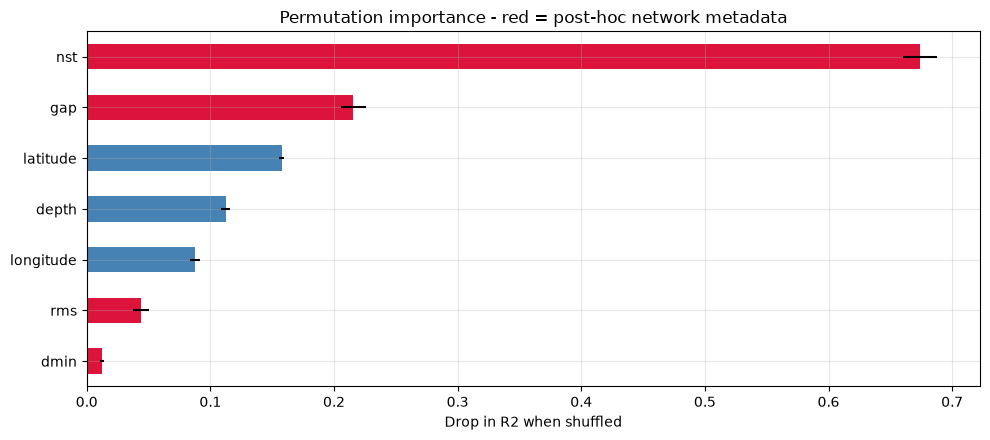

nst          0.6743
gap          0.2157
latitude     0.1578
depth        0.1124
longitude    0.0876
rms          0.0443
dmin         0.0124
dtype: float64


In [9]:
perm = permutation_importance(rf_rand, Xte, yte, n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=LEAK_FEATS).sort_values()

imp.plot(kind="barh", xerr=perm.importances_std[np.argsort(perm.importances_mean)],
         color=["crimson" if f in ("nst", "gap", "dmin", "rms") else "steelblue" for f in imp.index])
plt.title("Permutation importance - red = post-hoc network metadata")
plt.xlabel("Drop in R2 when shuffled")
plt.tight_layout(); plt.savefig(FIG_DIR / "leakage_importance.png", dpi=120); plt.show()

print(imp.sort_values(ascending=False).round(4))

In [10]:
d = df.copy()
d["ym"] = d["time"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
d["lat_bin"] = (np.floor(d["latitude"] / CELL_SIZE) * CELL_SIZE).astype(int)
d["lon_bin"] = (np.floor(d["longitude"] / CELL_SIZE) * CELL_SIZE).astype(int)
d["cell"] = d["lat_bin"].astype(str) + "_" + d["lon_bin"].astype(str)
d["energy"] = 10 ** (1.5 * d["mag"] + 4.8)      # Gutenberg-Richter energy in joules

cell_counts = d["cell"].value_counts()
keep = cell_counts[cell_counts >= MIN_EVENTS_PER_CELL].index
d = d[d["cell"].isin(keep)]
print(f"Kept {len(keep)} active cells covering {len(d):,} events "
      f"({len(d)/len(df):.0%} of the catalog)")

agg = d.groupby(["cell", "ym"]).agg(
    count      = ("mag", "size"),
    mag_mean   = ("mag", "mean"),
    mag_max    = ("mag", "max"),
    depth_mean = ("depth", "mean"),
    energy     = ("energy", "sum"),
)

months = pd.date_range(d["ym"].min(), d["ym"].max(), freq="MS")
full_idx = pd.MultiIndex.from_product([sorted(keep), months], names=["cell", "ym"])
panel = agg.reindex(full_idx)

panel["count"]    = panel["count"].fillna(0)
panel["energy"]   = panel["energy"].fillna(0)
panel["mag_max"]  = panel["mag_max"].fillna(0)          # 0 = "no event this month"
panel["mag_mean"] = panel["mag_mean"].fillna(0)
panel["depth_mean"] = (panel.groupby(level=0)["depth_mean"]
                            .transform(lambda s: s.ffill().bfill()))
panel["depth_mean"] = panel["depth_mean"].fillna(panel["depth_mean"].median())

print(f"Panel shape: {panel.shape}  ({len(keep)} cells x {len(months)} months)")
print(f"Zero-activity month rate: {(panel['count'] == 0).mean():.1%}")
panel.head()

Kept 162 active cells covering 192,968 events (84% of the catalog)
Panel shape: (71442, 5)  (162 cells x 441 months)
Zero-activity month rate: 37.0%


count  mag_mean  mag_max  depth_mean  energy
cell    ym                                                      
-10_-15 1990-01-01    0.0       0.0      0.0        10.0     0.0
        1990-02-01    0.0       0.0      0.0        10.0     0.0
        1990-03-01    0.0       0.0      0.0        10.0     0.0
        1990-04-01    0.0       0.0      0.0        10.0     0.0
        1990-05-01    0.0       0.0      0.0        10.0     0.0

In [11]:
# Feature engineering
g = panel.groupby(level=0)

panel["log_count"]  = np.log1p(panel["count"])
panel["log_energy"] = np.log1p(panel["energy"])

for w in (3, 6, 12):
    panel[f"count_ma{w}"]  = g["count"].transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
    panel[f"energy_ma{w}"] = g["log_energy"].transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())

panel["count_std12"] = g["count"].transform(lambda s: s.rolling(12, min_periods=1).std()).fillna(0)
panel["magmax_ma6"]  = g["mag_max"].transform(lambda s: s.rolling(6, min_periods=1).max())

panel["mag_sum"] = panel["mag_mean"] * panel["count"]
roll_magsum = g["mag_sum"].transform(lambda s: s.rolling(24, min_periods=1).sum())
roll_n      = g["count"].transform(lambda s: s.rolling(24, min_periods=1).sum())
mean_mag_24 = (roll_magsum / roll_n.replace(0, np.nan))
panel["b_value"] = (np.log10(np.e) / (mean_mag_24 - (MIN_MAG - 0.05))).clip(0, 3).fillna(1.0)


def months_since(flags):
    out, last = np.empty(len(flags)), -1
    for i, v in enumerate(flags):
        out[i] = (i - last) if last >= 0 else 120
        if v: last = i
    return np.minimum(out, 120)

panel["big_flag"] = (panel["mag_max"] >= BIG_MAG).astype(int)
panel["months_since_big"] = g["big_flag"].transform(lambda s: months_since(s.values))


mo = panel.index.get_level_values(1).month
panel["sin_month"] = np.sin(2 * np.pi * mo / 12)
panel["cos_month"] = np.cos(2 * np.pi * mo / 12)

# Targets: shift by -1 within each cell (next month) 
panel["target_count"] = g["count"].shift(-1)
panel["target_big"]   = g["big_flag"].shift(-1)

FEATURES = ["log_count", "mag_max", "mag_mean", "log_energy", "depth_mean",
            "count_ma3", "count_ma6", "count_ma12",
            "energy_ma3", "energy_ma6", "energy_ma12",
            "count_std12", "magmax_ma6", "b_value", "months_since_big",
            "sin_month", "cos_month"]

print(f"{len(FEATURES)} features per timestep")
print(f"Positive rate for 'M>={BIG_MAG} next month': {panel['target_big'].mean():.2%}")
panel[FEATURES].describe().T.round(2)

17 features per timestep
Positive rate for 'M>=5.5 next month': 13.14%


,count,mean,std,min,25%,50%,75%,max
log_count,71442.0,0.83,0.83,0.00,0.00,0.69,1.39,7.54
mag_max,71442.0,3.21,2.50,0.00,0.00,4.70,5.10,9.10
mag_mean,71442.0,3.04,2.34,0.00,0.00,4.60,4.83,7.50
log_energy,71442.0,18.29,14.09,0.00,0.00,27.29,29.20,42.51
depth_mean,71442.0,66.91,98.07,0.00,11.21,33.00,70.77,685.30
count_ma3,71442.0,2.70,8.18,0.00,0.33,1.33,2.67,822.67
count_ma6,71442.0,2.69,6.62,0.00,0.50,1.17,2.83,469.33
count_ma12,71442.0,2.68,5.43,0.00,0.58,1.25,2.91,262.92
energy_ma3,71442.0,18.29,10.52,0.00,9.33,18.96,28.72,37.69
energy_ma6,71442.0,18.28,9.37,0.00,9.65,18.88,28.03,36.80


In [12]:
def build_sequences(panel, features, seq_len=SEQ_LEN):
    X, y_cnt, y_big, dates, cells = [], [], [], [], []
    for cell, gdf in panel.groupby(level=0):
        gdf = gdf.sort_index(level=1)
        arr  = gdf[features].to_numpy(np.float32)
        tc   = gdf["target_count"].to_numpy(np.float32)
        tb   = gdf["target_big"].to_numpy(np.float32)
        idx  = gdf.index.get_level_values(1)
        for i in range(seq_len - 1, len(gdf)):
            if np.isnan(tc[i]):                       # last month has no target
                continue
            X.append(arr[i - seq_len + 1: i + 1])
            y_cnt.append(tc[i]); y_big.append(tb[i])
            dates.append(idx[i]); cells.append(cell)
    return (np.stack(X), np.array(y_cnt, np.float32), np.array(y_big, np.float32),
            pd.DatetimeIndex(dates), np.array(cells))

X, y_cnt, y_big, dates, cells_arr = build_sequences(panel, FEATURES)
print(f"X shape: {X.shape}   (samples, timesteps, features)")

tr_m = dates <= TRAIN_END
va_m = (dates > TRAIN_END) & (dates <= VAL_END)
te_m = dates > VAL_END

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X[tr_m].reshape(-1, X.shape[2]))
Xs = scaler.transform(X.reshape(-1, X.shape[2])).reshape(X.shape).astype(np.float32)

Xtr, Xva, Xte = Xs[tr_m], Xs[va_m], Xs[te_m]
ytr_c, yva_c, yte_c = y_cnt[tr_m], y_cnt[va_m], y_cnt[te_m]
ytr_b, yva_b, yte_b = y_big[tr_m], y_big[va_m], y_big[te_m]

# Regression on log1p(count) - counts are heavily right-skewed, MSE on raw counts
# would be dominated by aftershock bursts.
ytr_cl, yva_cl, yte_cl = np.log1p(ytr_c), np.log1p(yva_c), np.log1p(yte_c)

for name, m in [("train", tr_m), ("val", va_m), ("test", te_m)]:
    print(f"{name:<6} {m.sum():>7,} samples   "
          f"{dates[m].min().date()} -> {dates[m].max().date()}   "
          f"positive rate {y_big[m].mean():.2%}")

X shape: (69498, 12, 17)   (samples, timesteps, features)
train   44,874 samples   1990-12-01 -> 2013-12-01   positive rate 13.47%
val      9,720 samples   2014-01-01 -> 2018-12-01   positive rate 12.18%
test    14,904 samples   2019-01-01 -> 2026-08-01   positive rate 12.47%


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

def reg_metrics(y_true_log, y_pred_log, label):
    yt, yp = np.expm1(y_true_log), np.clip(np.expm1(y_pred_log), 0, None)
    r = {"model": label,
         "MAE": mean_absolute_error(yt, yp),
         "RMSE": mean_squared_error(yt, yp) ** 0.5,
         "R2": r2_score(yt, yp)}
    results.append(r)
    print(f"{label:<28} MAE {r['MAE']:.3f}   RMSE {r['RMSE']:.3f}   R2 {r['R2']:.3f}")
    return r

F = FEATURES
i_logcount = F.index("log_count"); i_ma3 = F.index("count_ma3")


Xte_raw = X[te_m]
persist = Xte_raw[:, -1, i_logcount]                     
ma3     = np.log1p(Xte_raw[:, -1, i_ma3])

reg_metrics(yte_cl, persist, "Persistence")
reg_metrics(yte_cl, ma3,     "Rolling mean (3m)")

clim = pd.Series(ytr_c).groupby(cells_arr[tr_m]).mean()
clim_pred = np.log1p(pd.Series(cells_arr[te_m]).map(clim).fillna(ytr_c.mean()).values)
reg_metrics(yte_cl, clim_pred, "Climatology (per cell)")

Persistence                  MAE 2.885   RMSE 12.788   R2 -0.371
Rolling mean (3m)            MAE 2.617   RMSE 11.189   R2 -0.050
Climatology (per cell)       MAE 2.368   RMSE 10.518   R2 0.072


{'model': 'Climatology (per cell)',
 'MAE': 2.368304491043091,
 'RMSE': 10.517734990415631,
 'R2': 0.07219809293746948}

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

Xtr_flat = Xtr.reshape(len(Xtr), -1)
Xva_flat = Xva.reshape(len(Xva), -1)
Xte_flat = Xte.reshape(len(Xte), -1)

gbm = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                    early_stopping=True, validation_fraction=0.15,
                                    random_state=RANDOM_STATE)
gbm.fit(np.vstack([Xtr_flat, Xva_flat]), np.concatenate([ytr_cl, yva_cl]))
reg_metrics(yte_cl, gbm.predict(Xte_flat), "Gradient boosting (flat)")

Gradient boosting (flat)     MAE 2.069   RMSE 10.171   R2 0.132


{'model': 'Gradient boosting (flat)',
 'MAE': 2.0688626378207013,
 'RMSE': 10.170707814519604,
 'R2': 0.13241280548356937}

In [15]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(RANDOM_STATE)
    TF_OK = True
    print("TensorFlow", tf.__version__)
except ImportError:
    TF_OK = False
    print("TensorFlow not installed -> run: pip install tensorflow")

def build_lstm(n_features, task="regression", seq_len=SEQ_LEN):
    m = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
        layers.LSTM(32, dropout=0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation=None if task == "regression" else "sigmoid"),
    ])
    if task == "regression":
        m.compile(optimizer=keras.optimizers.Adam(1e-3), loss=keras.losses.Huber(), metrics=["mae"])
    else:
        m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(name="pr_auc", curve="PR")])
    return m

TensorFlow not installed -> run: pip install tensorflow


In [16]:
if TF_OK:
    lstm_reg = build_lstm(Xtr.shape[2], "regression")
    lstm_reg.summary()

    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
          keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

    hist_reg = lstm_reg.fit(Xtr, ytr_cl, validation_data=(Xva, yva_cl),
                            epochs=120, batch_size=128, callbacks=cb, verbose=0)

    plt.plot(hist_reg.history["loss"], label="train")
    plt.plot(hist_reg.history["val_loss"], label="val")
    plt.title("LSTM (count regression) - Huber loss"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout(); plt.savefig(FIG_DIR / "lstm_reg_curve.png", dpi=120); plt.show()

    pred_lstm = lstm_reg.predict(Xte, verbose=0).ravel()
    reg_metrics(yte_cl, pred_lstm, "LSTM")

In [17]:
if TF_OK:
    res = pd.DataFrame(results).set_index("model").round(3)
    print("Next-month event count - test window ({} onward)\n".format(pd.Timestamp(VAL_END).year + 1))
    print(res)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    res["MAE"].plot(kind="barh", ax=ax[0], color="steelblue"); ax[0].set_title("MAE (lower is better)")
    res["R2"].plot(kind="barh", ax=ax[1], color="seagreen");   ax[1].set_title("R2 (higher is better)")
    plt.tight_layout(); plt.savefig(FIG_DIR / "model_comparison.png", dpi=120); plt.show()

In [18]:

if TF_OK:
    te_df = pd.DataFrame({"cell": cells_arr[te_m], "ym": dates[te_m],
                          "actual": yte_c, "pred": np.clip(np.expm1(pred_lstm), 0, None)})
    top3 = te_df.groupby("cell")["actual"].sum().nlargest(3).index

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    for axx, c in zip(axes, top3):
        s = te_df[te_df["cell"] == c].sort_values("ym")
        axx.plot(s["ym"], s["actual"], label="actual", lw=1.6)
        axx.plot(s["ym"], s["pred"], label="LSTM forecast", lw=1.6, ls="--")
        axx.set_title(f"Cell {c} (lat_lon of SW corner)"); axx.legend()
    plt.tight_layout(); plt.savefig(FIG_DIR / "forecast_vs_actual.png", dpi=120); plt.show()

In [19]:
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_curve)

clf_results = []
def clf_metrics(y_true, p, label, ref_brier=None):
    r = {"model": label,
         "ROC-AUC": roc_auc_score(y_true, p),
         "PR-AUC": average_precision_score(y_true, p),
         "Brier": brier_score_loss(y_true, p)}
    if ref_brier is not None:
        r["Brier skill"] = 1 - r["Brier"] / ref_brier
    clf_results.append(r); return r


base = pd.Series(ytr_b).groupby(cells_arr[tr_m]).mean()
p_clim = pd.Series(cells_arr[te_m]).map(base).fillna(ytr_b.mean()).values
ref_b = brier_score_loss(yte_b, p_clim)
clf_metrics(yte_b, p_clim, "Climatology (per cell)", ref_b)

gclf = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                      early_stopping=True, random_state=RANDOM_STATE)
gclf.fit(np.vstack([Xtr_flat, Xva_flat]), np.concatenate([ytr_b, yva_b]))
clf_metrics(yte_b, gclf.predict_proba(Xte_flat)[:, 1], "Gradient boosting", ref_b)

if TF_OK:
    pos_w = (len(ytr_b) - ytr_b.sum()) / max(ytr_b.sum(), 1)
    lstm_clf = build_lstm(Xtr.shape[2], "classification")
    cb2 = [keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                         patience=12, restore_best_weights=True)]
    hist_clf = lstm_clf.fit(Xtr, ytr_b, validation_data=(Xva, yva_b),
                            epochs=120, batch_size=128, callbacks=cb2, verbose=0,
                            class_weight={0: 1.0, 1: float(np.sqrt(pos_w))})
    p_lstm = lstm_clf.predict(Xte, verbose=0).ravel()
    clf_metrics(yte_b, p_lstm, "LSTM", ref_b)

print(f"\nP(M >= {BIG_MAG} next month) - test window\n")
print(pd.DataFrame(clf_results).set_index("model").round(4))


P(M >= 5.5 next month) - test window

                        ROC-AUC  PR-AUC   Brier  Brier skill
model                                                       
Climatology (per cell)   0.7486  0.3162  0.0979       0.0000
Gradient boosting        0.7395  0.3221  0.0977       0.0015


In [20]:
if TF_OK:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    for p, lab in [(p_clim, "Climatology"), (gclf.predict_proba(Xte_flat)[:, 1], "GBM"), (p_lstm, "LSTM")]:
        fpr, tpr, _ = roc_curve(yte_b, p); ax[0].plot(fpr, tpr, label=lab)
        pr, rc, _ = precision_recall_curve(yte_b, p); ax[1].plot(rc, pr, label=lab)
    ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set_title("ROC"); ax[0].legend()
    ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
    ax[1].axhline(yte_b.mean(), color="k", ls="--", lw=0.8)
    ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()

  
    bins = np.linspace(0, min(1, p_lstm.max() + 0.05), 11)
    b_id = np.digitize(p_lstm, bins) - 1
    obs = [yte_b[b_id == k].mean() if (b_id == k).sum() > 20 else np.nan for k in range(len(bins) - 1)]
    mid = [p_lstm[b_id == k].mean() if (b_id == k).sum() > 20 else np.nan for k in range(len(bins) - 1)]
    ax[2].plot(mid, obs, "o-", label="LSTM")
    ax[2].plot([0, 1], [0, 1], "k--", lw=0.8)
    ax[2].set_xlim(0, np.nanmax(mid) * 1.1); ax[2].set_ylim(0, 1)
    ax[2].set_title("Calibration"); ax[2].set_xlabel("Predicted P"); ax[2].set_ylabel("Observed frequency")
    ax[2].legend()

    plt.tight_layout(); plt.savefig(FIG_DIR / "classification_eval.png", dpi=120); plt.show()

---
## 7. Persisting artifacts

In [21]:
import joblib

artifact = {
    "scaler": scaler,
    "features": FEATURES,
    "seq_len": SEQ_LEN,
    "cell_size_deg": CELL_SIZE,
    "min_mag": MIN_MAG,
    "big_mag": BIG_MAG,
    "splits": {"train_end": TRAIN_END, "val_end": VAL_END},
    "gbm_regressor": gbm,
    "gbm_classifier": gclf,
}
joblib.dump(artifact, OUT_DIR / "preprocessing_and_baselines.joblib")

if TF_OK:
    lstm_reg.save(OUT_DIR / "lstm_count_regressor.keras")
    lstm_clf.save(OUT_DIR / "lstm_big_event_classifier.keras")
    pd.DataFrame(results).to_csv(OUT_DIR / "regression_results.csv", index=False)
    pd.DataFrame(clf_results).to_csv(OUT_DIR / "classification_results.csv", index=False)

try:
    panel.to_parquet(OUT_DIR / "monthly_panel.parquet")
except Exception:
    panel.to_csv(OUT_DIR / "monthly_panel.csv")   
print("Artifacts written to", OUT_DIR.resolve())

Artifacts written to C:\Users\Lenovo\Desktop\Projects\Earthquake DL\outputs
